In [1]:
# Import necessary libraries
import multiprocessing
if __name__ == "__main__":
    # Spawn is safer compared to fork, and is required to avoid deadlocks
    # with Numpy,SciPy,Torch, or any library that uses CPython or a low level language with multithreading.
    multiprocessing.set_start_method("spawn",force=True)
import os
from psutil import cpu_count
# Get CPython libraries to only use 75% of the threads the CPU has.
TOTAL_THREAD_COUNT = cpu_count()
THREAD_COUNT = TOTAL_THREAD_COUNT // 2 if TOTAL_THREAD_COUNT > 2 else 1

# Prevents low-level language libraries from manually managing threads.
# This is needed because deadlocking can easily occur if both the library and this script is competing for cores.
os.environ["OMP_NUM_THREADS"] = str(THREAD_COUNT)
os.environ["MKL_NUM_THREADS"] = str(THREAD_COUNT)
os.environ["OPENBLAS_NUM_THREADS"] = str(THREAD_COUNT)

import warnings
warnings.filterwarnings("ignore") # Ignores all warnings

import sys
sys.path.append("scripts")
sys.path.append("scripts/process_pdb_scripts")
from cnn_mlp_encoder import ProteinPhysicsEncoder, get_hamiltonian
from pdb_voxelizier import protein_to_tensor
import jw_quantum_mapper as jw_mapper
from verify_twin_pipeline import run_verification
from fetch_catalytic_sites import fetch_catalytic_sites
from hydrogen_capping import add_hydrogen_atoms
from export_residue_as_pdb import export_residue
import torch # To use our neural network
import numpy as np
from pretrain_CNN import return_pretrained_CNN

# Graphing training results
import matplotlib.pyplot as plt

# Import Variational Quantum Eigensolver (VQE) tools needed
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock,UCC
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.circuit.library import efficient_su2
from qiskit_algorithms import VQE,AdaptVQE
from qiskit_algorithms.optimizers import SLSQP,COBYLA
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2,Estimator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.quantum_info import SparsePauliOp


# PROBLEM:
# FIGURE OUT WHY pdb_process SOMETIMES FAILS TO FIND ANY ATOMS

# PROBLEM 2:
# REMOVE UNNECESSARY COMMENTS IN THE CODEPATH AND PROPERLY DOCUMENT FUNCTIONS

In [2]:
# Declare parameters here!
VOXEL_GRID_SIZE = 32 # e.g. 32 x 32 x 32 , higher value = higher resolution voxel.
GRAPH_DISTANCE_THRESHOLD = 5.0 # Must be floating point number, higher number = more detailed graph.
NUM_SITES = 3 # The amount of catalytic residues to simulate (a catalytic triad!)
DEVICE = "cuda"
torch.device(DEVICE)

device(type='cuda')

1. Generate a 3-Dimensional Convolutional Neural Network (3DCNN) and pretrain it via a Graph Neural Network (GNN) 

In [3]:
# Declare variables
# First, declare the directory where the training and validation proteins are (relative to this Jupyter,file of course).
PRETRAIN_PROTEIN_DIR = "proteins/training_proteins"
PRETRAIN_VALIDATION_DIR = "proteins/validation_proteins"

# Second, decide maximum amount of iterations allowed:
PRETRAIN_MAX_ITERATIONS = 100 # 100 is a safe bet

# Third, decide loss threshold. Typically we want predictions to be under the
# chemical accuracy threshold of 0.043 eV.
PRETRAIN_LOSS_THRESHOLD = 0.001 # Should ensure that all proteins are accurate enough

# Fourth, decide batch size. Typically 32 is fine.
PRETRAIN_BATCH_SIZE = 32

# Last, decide the learning rate for the optimizer
PRETRAIN_LR = 0.001

WARNING: The following code cell can be particularly rough on your CPU

In [4]:
# Generate 3DCNN, saves to ./__temp__/models as protein_cnn.pt
print("Pre-training 3DCNN!")
print("--------------------------")
loss_history,validation_loss_history = return_pretrained_CNN(
    test_set_dir=PRETRAIN_PROTEIN_DIR,
    validation_set_dir=PRETRAIN_VALIDATION_DIR,
    num_sites=NUM_SITES,
    grid_size=VOXEL_GRID_SIZE,
    distance_threshold=GRAPH_DISTANCE_THRESHOLD,
    max_iterations=PRETRAIN_MAX_ITERATIONS,
    loss_threshold=PRETRAIN_LOSS_THRESHOLD,
    batch_size=PRETRAIN_BATCH_SIZE,
    lr=PRETRAIN_LR
    )
print("--------------------------\n")
# We're returned a list of proteins that failed to meet MAE, the code below
# prints out the exact results of proteins that the model failed to learn from the GNN.
# if len(failed_training_proteins_list) == 0:
    # print(f"Training success! All proteins met MAE threshold of 5% error or below!")
# else:
#     print("Recommended MAE is 5%, here are the protein(s) that failed to meet that threshold:")    
#     for item in failed_training_proteins_list:
#         loss_percent = str(f"{(item[1] * 100):.2f}")
#         print(f"{item[0]} had MAE of {loss_percent}%")
# print("--------------------------\n")

# Verify (with some test proteins), that the pretrained CNNs predictions are within chemical accuracy (0.043 eV)

# Returns (Bool, mean average error, minimum eigenvalue error or Delta_E)
print("Verifying Pre-trained 3DCNN!")
print("--------------------------")
failed = run_verification(
    test_protein_dir=PRETRAIN_VALIDATION_DIR,
    num_sites=NUM_SITES,
    grid_size=VOXEL_GRID_SIZE,
    distance_threshold=GRAPH_DISTANCE_THRESHOLD
    )

if failed:
    print("The following proteins failed verification: ")
    for name, results in failed.items():
        mae_percent = str(f"{(results[0]*100):.2f}")
        delta_e = str(f"{(results[1]*100):.2f}")
        print(f"{name}: MAE = {mae_percent}%, Delta_E = {delta_e}%")
else:
    print("3DCNN passed verification on the test protein dataset!")
print("--------------------------")

Pre-training 3DCNN!
--------------------------
Successfully pre-trained CNN model with loss total of 0.000051 at 37 epochs.
--------------------------

Verifying Pre-trained 3DCNN!
--------------------------
3DCNN passed verification on the test protein dataset!
--------------------------


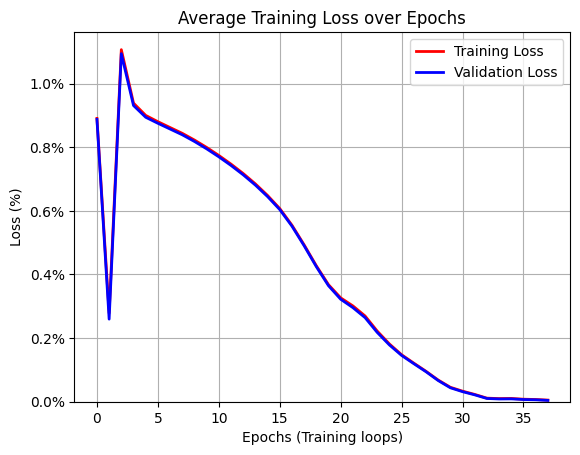

In [5]:
# Plot loss history and validation loss history
# Here, we want both to converge at the same value. 
# If total loss converges but validation loss doesn't, 
# it means we might be overfitting and need to adjust our loss threshold.
fig, ax = plt.subplots()

percent_loss_history = [x*100 for x in loss_history]
percent_validation_loss_history = [x*100 for x in validation_loss_history]
x_axis = [x for x in range(0,len(loss_history))]
ax.plot(x_axis,percent_loss_history,label='Training Loss' ,linewidth=2,color='red')
ax.plot(x_axis,percent_validation_loss_history,label="Validation Loss",linewidth=2,color='blue')

plt.ylabel("Loss (%)")
plt.xlabel("Epochs (Training loops)")
plt.title("Average Training Loss over Epochs")
plt.grid(visible=True)

ax.yaxis.set_major_formatter(lambda x, pos:f"{x:.1f}%" )
ax.set_ylim(ymin=0)
plt.legend()
plt.show()

3. Use real Density Functional Theory (DFT) calculations to train the 3DCNN

3. Make real coefficient predictions using the CNN!

In [ ]:
# Grab the trained CNN model
CNN_MODEL_PATH = "__temp__/models/protein_cnn.pt" # Currently using pretrained CNN 
CNN_MODEL = ProteinPhysicsEncoder(num_sites=NUM_SITES) # Create a dummy model and load in trained weights
CNN_MODEL.load_state_dict(torch.load(CNN_MODEL_PATH))

# Determine the protein that will have predictions made on it.
PROTEIN = "proteins/1A7R.pdb"

# Turn protein into a voxel tensor (as a numpy array)
PROTEIN_VOXEL = pdb_to_tensor(pdb_filepath=PROTEIN,grid_size=VOXEL_GRID_SIZE)

# Get hamiltonian from the coefficient predictions
HAMILTONIAN = get_hamiltonian(PROTEIN_VOXEL,NUM_SITES)


if len(HAMILTONIAN) <= 36:
    np.set_printoptions(suppress=True,precision=5)
    print(HAMILTONIAN)

4. Use predicted coefficients to construct qubit operators that could theoretically be run on a real quantum computer.

In [ ]:
# Convert coefficients directly into qubit operators using an implicit Jordan Wigner conversion
COEFFS = HAMILTONIAN
JW_QUBIT_OPERATORS = jw_mapper.apply_jw(coefficients=COEFFS,num_sites=NUM_SITES)

# Convert Qubit Operators directly into pauli operators (since quantum computers typically use Pauli gates)
PAULI_OP_HAMILTONIAN = jw_mapper.convert_qubit_operators_to_pauli_operators(JW_QUBIT_OPERATORS,NUM_SITES)

# Convert puali operators into a Quantum Hamiltonian matrix that can be simulated
PAULI_MATRIX_HAMILTONIAN = PAULI_OP_HAMILTONIAN.to_matrix()

# We don't need the original PAULI_OP_HAMILTONIAN anymore, or the qubit operators
# del JW_QUBIT_OPERATORS, PAULI_OP_HAMILTONIAN

# Hamiltonians are typically very very large, however in this case we're working with much simpler 2D Hamiltonians:
print(f"Hamiltonian Dimension: {len(PAULI_MATRIX_HAMILTONIAN)} x {len(PAULI_MATRIX_HAMILTONIAN)}")

# Additionally, derive the estimated minimum eigenvalue to compare against our VQE later.
# This is purely to verify that the VQE correctly setup, and does not prove that the original qubit operators is accurately depicting the energy structure.
ESTIMATED_MINIMUM_EIGENVALUE = np.linalg.eigvalsh(PAULI_MATRIX_HAMILTONIAN)[0]
print(f"Estimated Minimum Eigenvalue via diagonalization: {ESTIMATED_MINIMUM_EIGENVALUE}")

In [ ]:
# We can get particle count by taking the conjugate of the Hamiltonian matrix
ground_matrix = np.linalg.eigvalsh(PAULI_MATRIX_HAMILTONIAN) 
val = ground_matrix.conj() @ PAULI_OP_HAMILTONIAN.to_matrix() @ ground_matrix

# print(val)
print(PAULI_OP_HAMILTONIAN)

In [ ]:
# Example code for calculating particle counts
eigvals, eigvecs = np.linalg.eigh(PAULI_MATRIX_HAMILTONIAN)
ground_state = eigvecs[:, 0]     # eigh sorts ascending
ground_energy = eigvals[0]

string_sites = NUM_SITES * 2

# We need operators to use for deriving particle count
number_operators = []

for i in range(NUM_SITES):
    start_str = ["I"] * string_sites
    start_str[i] = "Z"
    # We use the same design as in jw_quantum_mapper and skip the identity term.
    z_op = SparsePauliOp("".join(start_str))
    n_i = 0.5 * (z_op)
    number_operators.append(n_i)
    
N_total = sum(number_operators)
N_matrix = N_total.to_matrix()

coef = np.diag(PAULI_MATRIX_HAMILTONIAN)

# In the form of |x_i> N <x_i|, to calculate the particle count
true_particle_count = ground_state.conj() @ N_matrix @ ground_state

# Should produce an integer number, will produce garbage if CNN is not trained (i.e. its outputs are nonsense)
print(f"Particle count: {true_particle_count}")

5. Calculate Alpha and Beta particle counts to implement the UCCSD Asatz. 

This is necessary so that we can extract necessary qubit operator pools needed to run the ADAPT-VQE algorithm.

In [ ]:
# So, we know that we have NUM_SITES amount of energy sites, which we will call "spatial orbitals"
# In the tight-binding hamiltonian, site-energies are the energy of a particular electron (residue, in this case), when ignoring the influence of other nearby electrons
# (Reference: https://fiveable.me/solid-state-physics/unit-5/tight-binding-model/study-guide/ , Specifically section 5.2: Tight Binding Model) 

# These site-energies are exactly what we need to calculate Alpha/Beta particle counts.
# We need to map these energies onto some particular element

# 1. Define your system physics
num_spatial_orbitals = NUM_SITES
num_particles = (NUM_SITES//2,NUM_SITES//2) # Alpha and Beta electrons
mapper = JordanWignerMapper()

# 2. Let UCCSD define the pool!
# By passing this to AdaptVQE, Qiskit automatically breaks the UCCSD
# ansatz down into a pool of individual Singles and Doubles excitations.
hartree = HartreeFock(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper
)

ansatz = UCCSD(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper,
    initial_state=hartree,
    include_imaginary=False,
    generalized=True
)

# 3. 
optimizer = SLSQP(maxiter=100)
# optimizer = COBYLA(maxiter=1000)

estimator = StatevectorEstimator(default_precision=0.0,seed=None)
vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)

# 4. Run ADAPT-VQE
# ADAPT will pull the singles and doubles out of the ansatz to form its pool.
adapt_vqe = AdaptVQE(
    solver=vqe,
    gradient_threshold=1e-5,
    max_iterations=15, # Max iterations for adaptive loop (i.e. Maximum circuit depth)
)

result = adapt_vqe.compute_minimum_eigenvalue(PAULI_OP_HAMILTONIAN)

print(f"Number of ADAPT-VQE iterations done: {result.num_iterations}/{adapt_vqe.max_iterations}")
print(f"VQE Result: {result.optimal_value:.5f}")
print(f"Actual Result: {ESTIMATED_MINIMUM_EIGENVALUE:.5f}")
print(f"Reason for Ending: {result.termination_criterion}")
print(result.optimal_circuit)